## Another tool in your toolbelt: Python OSMnx for Geographical Street Analysis

#### What is OSMnx?
OSMnx is a Python package designed to simplify the process of downloading, modeling, visualizing, and analyzing street networks. With just a single line of code, you can acquire a street network for any city or neighborhood, whether it’s walkable paths, drivable roads, or bike routes. Beyond streets, OSMnx can also retrieve building footprints, points of interest, elevation data, and even street orientations.

For example, generating a visual of the street network for Modena, Italy, requires just:

#### conda activate geo_env

In [1]:
import osmnx as ox


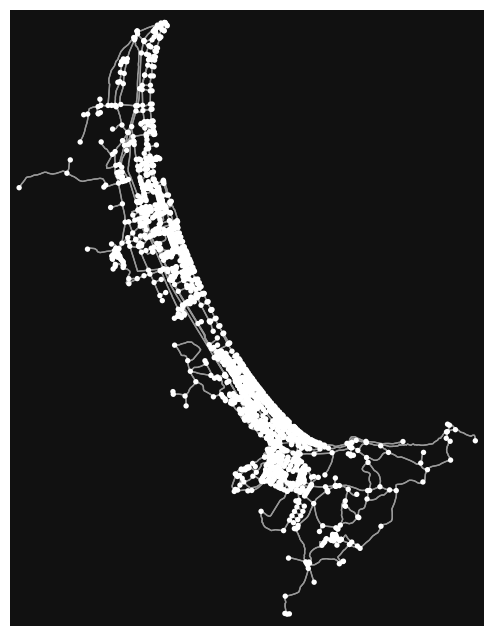

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
ox.plot_graph(ox.graph_from_place('Binz, Germany'))

#### Key Features of OSMnx
OSMnx is incredibly versatile. Some of its standout capabilities include:

Street Network Acquisition: Download networks for driving, walking, biking, or all available streets.
Flexible Data Queries: Retrieve networks by city name, bounding box, polygon, or coordinates.
Spatial Analysis: Calculate network metrics, node centrality, street orientations, and travel distances.
Data Export: Save networks as shapefiles, GraphML, GeoPackages, or SVGs for further GIS or design use.
Routing: Compute shortest paths based on distance, travel time, or elevation.
Topology Simplification: Automatically consolidate intersections and clean up network geometry.

#### Five Practical OSMnx Use Cases
1. Fetching Administrative Boundaries
Getting shapefiles for administrative areas can be tedious, but OSMnx simplifies this:

Old Way (v1.x)	New Way (v2.x)
ox.project_gdf()	ox.projection.project_gdf()
ox.save_graph_shapefile()	ox.io.save_graph_shapefile()
ox.get_nearest_node()	ox.distance.nearest_nodes()
ox.plot_graph_folium()	ox.folium.plot_graph_folium()

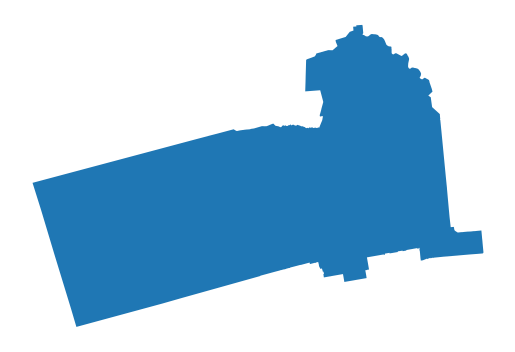

In [3]:
# Get the city boundary
city = ox.geocode_to_gdf('Berkeley, California')

# Project the GeoDataFrame (moved to the projection module)
city_projected = ox.projection.project_gdf(city)

# Plot
ax = city_projected.plot()
_ = ax.axis('off')

You can retrieve boundaries for cities, counties, states, or even entire countries and combine multiple places into a single dataset.

#### 2. Downloading and Modeling Street Networks
OSMnx allows flexible network downloads:

By Bounding Box:

In [8]:
import osmnx as ox

# 1. Clear old bad settings
ox.settings.use_cache = True # Cache is your friend to avoid repeated requests
ox.settings.log_console = True
ox.settings.timeout = 60

# 2. Use the main reliable server
ox.settings.overpass_url = "https://overpass-api.de/api/interpreter"

# 3. IDENTIFY YOURSELF (Crucial to avoid 403)
# Replace 'yourname' with your actual name or email
ox.settings.user_agent = "OSMnx_Python_Research_Project_Contact_yourname@email.com"

# 4. Remove the 'verify=False' we added earlier
ox.settings.requests_kwargs = {} 

bbox = (37.79, 37.78, -122.41, -122.43)

try:
    print("Sending request with proper headers...")
    G = ox.graph_from_bbox(bbox=bbox, network_type='drive')
    print("Success!")
    
    G_projected = ox.projection.project_graph(G)
    ox.plot_graph(G_projected)
except Exception as e:
    print(f"Failed with: {e}")

Sending request with proper headers...


KeyboardInterrupt: 

By Point or Address: Download networks within a specific distance from a location.
By Place Name or Polygon: Acquire entire neighborhoods, districts, or cities with minimal code.

#### 3. Simplifying Network Topology
Raw street data often contains extraneous nodes where streets curve, which are not actual intersections. OSMnx simplifies networks to retain only meaningful junctions while preserving geometry:

In [5]:
G_simplified = ox.simplify_graph(G)

GraphSimplificationError: This graph has already been simplified, cannot simplify it again.

This makes the network cleaner and more suitable for analysis.

#### 4. Saving Networks for Later Use
You can export networks for future use:

GraphML: For analysis in NetworkX or Gephi.
Shapefiles/GeoPackages: For GIS applications like QGIS.
SVGs: For design purposes in vector graphics editors.
#### 5. Analyzing and Visualizing Networks
OSMnx leverages NetworkX and geopandas to compute network statistics and visualize them:

In [ ]:
G = ox.graph_from_place('Santa Monica, California', network_type='walk')
basic_stats = ox.basic_stats(G)
print(basic_stats['circuity_avg'])

extended_stats = ox.extended_stats(G, bc=True)
print(extended_stats['betweenness_centrality_avg'])

1.0441636266852448


AttributeError: module 'osmnx' has no attribute 'extended_stats'

You can also compute shortest paths, generate figure-ground diagrams, visualize street orientations, or create isochrone maps showing areas reachable within a given travel time.

OSMnx bridges the gap between raw geographic data and actionable insights for urban networks. It automates the tedious steps of data acquisition, cleaning, and visualization, empowering researchers, planners, and developers to focus on analysis and decision-making. Built on top of NetworkX, geopandas, and matplotlib, it offers both computational rigor and visual elegance for anyone working with spatial networks.

Whether you’re studying pedestrian accessibility, planning urban infrastructure, or analyzing street network connectivity, OSMnx offers a robust toolkit to make your work faster, more consistent, and reproducible.

